In [31]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from src.utils import read_obs, latexify_xlabel, save_figure

In [32]:
obs = read_obs("/root/capsule/data/filtered_adata/CaH_final_nuclei.2025-12-29.h5ad")

In [33]:
obs["Supertype"] = obs["Supertype"].str.replace("Supertype", "")
obs["Neighborhood"] = obs["Neighborhood"].str.replace("Neighborhood", "")
obs["library"] = obs.index.map(lambda x: x.split("-")[1])

In [34]:
neurons = ['LGE','MGE', 'CGE', 'LSX ', 'OB']
non_neurons = ['Astro-Epen', 'Immune', 'Vascular', 'OPC-Oligo',]
neuron_obs = obs[obs["Neighborhood"].isin(neurons)]
non_neuron_obs = obs[obs['Neighborhood'].isin(non_neurons)]

In [35]:
mean_cell_props = neuron_obs.groupby("library")["Supertype"].value_counts(normalize = True).unstack("Supertype").mean()
big_neurons = mean_cell_props[mean_cell_props > 0.01].index.tolist()
mean_cell_props = non_neuron_obs.groupby("library")["Supertype"].value_counts(normalize = True).unstack("Supertype").mean()
big_non_neurons = mean_cell_props[mean_cell_props > 0.01].index.tolist()
big_cells = big_neurons + big_non_neurons

In [36]:
cell_bool = obs.groupby("Donor ID")["Supertype"].value_counts().unstack("Supertype").apply(lambda x: np.any(x < 10))
cells_to_remove= cell_bool[cell_bool].index 

/tmp/ipykernel_768501/3558100039.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_bool = obs.groupby("Donor ID")["Supertype"].value_counts().unstack("Supertype").apply(lambda x: np.any(x < 10))


In [37]:
results = pd.read_csv("/data/Supplemental Tables/Supplemental Table 3.csv", index_col = 0)

In [38]:
rel_results = results[results["Covariate"].isin(["CPS", "CPS_AT8", "CPS_6e10"])]
rel_results["Regressor"] = rel_results["Covariate"].apply({x:latexify_xlabel(x) for x in ["CPS", "CPS_AT8", "CPS_6e10"]}.get)
rel_results = rel_results[~(rel_results["Cell Type"].isin(cells_to_remove))]

/tmp/ipykernel_768501/1863124952.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rel_results["Regressor"] = rel_results["Covariate"].apply({x:latexify_xlabel(x) for x in ["CPS", "CPS_AT8", "CPS_6e10"]}.get)


In [39]:
sig_cells = []
for i in ["CPS", "CPS_AT8", "CPS_6e10"]:
    p_inclusion = rel_results[(rel_results["Regressor"] == latexify_xlabel(i)) & (rel_results["Reference Cell Type"].isin(big_cells))].groupby("Cell Type")["Inclusion probability"].mean()
    sig_cells.extend(p_inclusion[p_inclusion > 0.85].index.tolist())
    print(sig_cells)
sig_cells = list(set(sig_cells))

[]
['Astro_2', 'Micro-PVM_2_3-SEAAD']
['Astro_2', 'Micro-PVM_2_3-SEAAD']


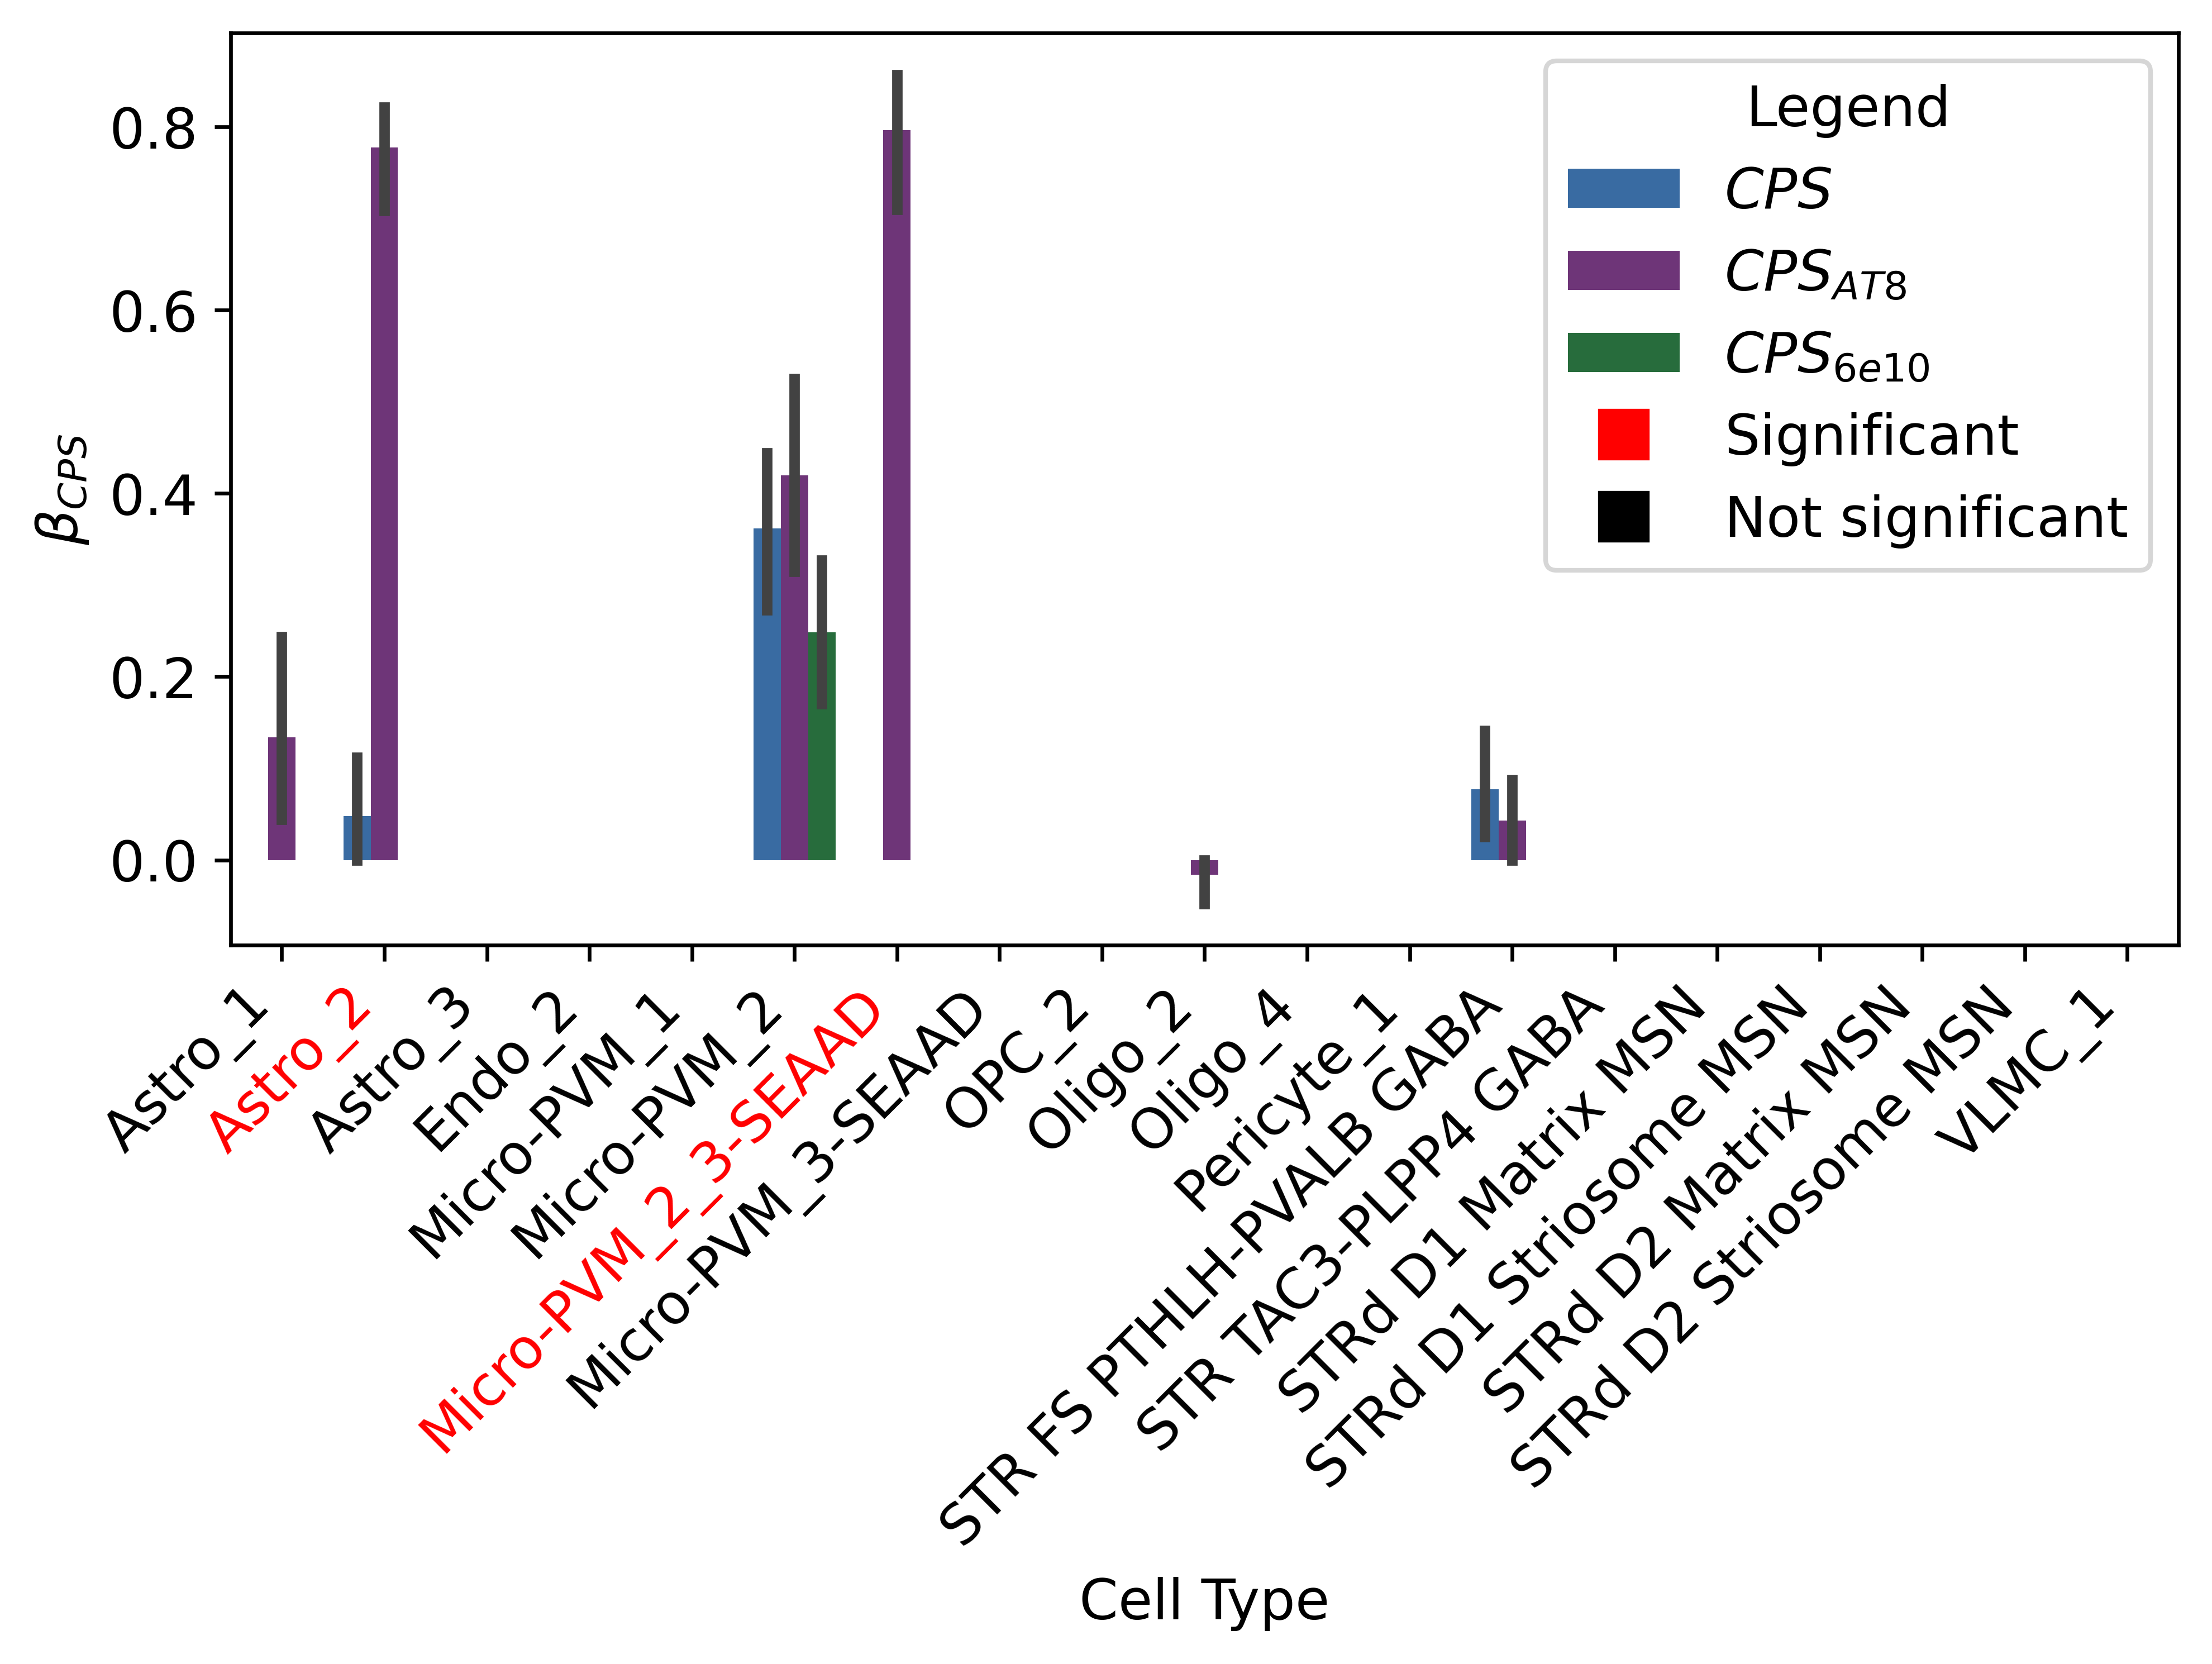

In [42]:
from matplotlib import lines as mlines
with plt.rc_context({"figure.dpi":600, "figure.figsize":(15/2, 15/6*1.414), "font.size": 12}):
    scatter = sns.barplot(x = "Cell Type", y = "Final Parameter", hue = "Regressor", data = rel_results[~rel_results["Cell Type"].isin(cells_to_remove)].sort_values("Cell Type"), hue_order = [latexify_xlabel(x) for x in ["CPS", "CPS_AT8", "CPS_6e10"]],  palette = ['#276AB3', "#762a83", "#1b7837"],)
    plt.xticks(rotation = 45,ha = "right")
    plt.ylabel(r"$\beta_{CPS}$")
    plt.xlabel("Cell Type")
    xlabels = [tick.get_text() for tick in scatter.get_xticklabels()]
    plt.xticks(range(len(xlabels)), xlabels)
    for tick in scatter.get_xticklabels():
        if (tick.get_text() in sig_cells):
            tick.set_color("Red")
        # elif (tick.get_position()[1] >= 31):
        #     tick.set_color("Purple")
    # Red Square for Significant
    sig_handle = mlines.Line2D([], [],
                               color='red',           # Edge/Marker color
                               marker='s',            # Square marker
                               linestyle='None',      # No connecting line
                               markersize=10,         # Adjust size for legend clarity
                               label='Significant')
    
    # Black Square for Not Significant
    not_sig_handle = mlines.Line2D([], [],
                                   color='black',
                                   marker='s',
                                   linestyle='None',
                                   markersize=10,
                                   label='Not Significant')
    
    handles, labels = scatter.get_legend_handles_labels()
    handles.extend([sig_handle, not_sig_handle])
    labels.extend(['Significant', 'Not significant'])
    plt.legend(handles=handles, labels=labels, title='Legend', loc='upper right')
    plt.savefig(
        '/scratch/Figure3_Pertpy.svg',
        bbox_inches='tight',
    )
    plt.show()

## Supplmental Figure 

In [11]:
neuron_types = neuron_obs['Supertype'].unique()
non_neuron_types = non_neuron_obs['Supertype'].unique()

In [12]:
df = pd.read_csv("/root/capsule/data/Supplemental Tables/Supplemental Table 3.csv", index_col = 0)

In [13]:
conversion = {'CPS_AT8':r'$CPS_{AT8}$', 'CPS_6e10':r'$CPS_{6E10}$', 'ADNC_codes':'ADNC', 'Thal_codes':'Thal', 'Braak_codes':"Braak"}
rel_df = df[df['Covariate'].isin(['CPS_AT8', 'CPS_6e10', 'ADNC_codes', 'Thal_codes', 'Braak_codes'])].replace(conversion)

In [14]:
neuron_df = rel_df[(rel_df['Cell Type'].isin(neuron_types)) & (rel_df['Reference Cell Type'].isin(big_neurons))]
non_neuron_df = rel_df[rel_df['Cell Type'].isin(non_neuron_types) & (rel_df['Reference Cell Type'].isin(big_non_neurons))]

In [15]:
neuron_comparison = neuron_df.pivot_table(index = ['Cell Type', 'Reference Cell Type',], columns = ['Covariate'], values = 'Final Parameter').reset_index()
non_neuron_comparison = non_neuron_df.pivot_table(index = ['Cell Type', 'Reference Cell Type',], columns = ['Covariate'], values = 'Final Parameter').reset_index()

In [28]:
from scipy.stats import pearsonr
def cat2codes(x):
    if x.dtype == "category":
        return x.cat.codes.astype(int)
    else:
        return x

def scatter_with_corr(x, y, **kwargs):
    x = cat2codes(x)
    y = cat2codes(y)
    ax = plt.gca()
    mask = x.notna() & y.notna()
    x, y = x[mask], y[mask]

    sns.scatterplot(x=x, y=y, alpha=0.5, ax=ax)

    # pearson correlation
    r, p = pearsonr(x, y)
    ax.annotate(f'$R^2$ = {r**2:.2f}\np = {p:.3f}',
            xy=(0.05, 0.95), xycoords='axes fraction',
            ha='left', va='top', fontsize=12,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    # equal axes, forced to include the origin
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    lims = [lo, hi]
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    # ax.set_aspect('equal', adjustable='box')

    # reference lines at the origin
    ax.axhline(0, color='gray', lw=0.8, alpha=0.5, zorder=0)
    ax.axvline(0, color='gray', lw=0.8, alpha=0.5, zorder=0)

    # diagonal reference line
    ax.plot(lims, lims, ls='--', color='red', alpha=0.5, zorder=0)

Saved: /scratch/SupplementalFigure1_CPSAT8vOrdinal_neuronal_scCODA.svg
Saved: /scratch/SupplementalFigure1_CPSAT8vOrdinal_neuronal_scCODA.png


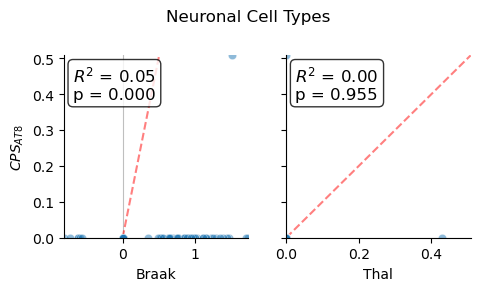

Saved: /scratch/SupplementalFigure1_CPSAT8vOrdinal_non_neuronal_scCODA.svg
Saved: /scratch/SupplementalFigure1_CPSAT8vOrdinal_non_neuronal_scCODA.png


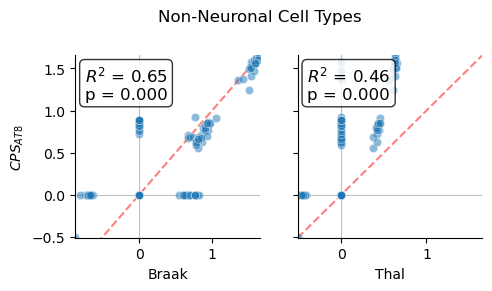

In [30]:
#Neurons
#AT8
g = sns.PairGrid(neuron_comparison, x_vars = ['Braak', 'Thal'], y_vars = [r'$CPS_{AT8}$'],)
g.fig.suptitle("Neuronal Cell Types", y=1.125)
g.map(scatter_with_corr)
save_figure(g, "/scratch/SupplementalFigure1_CPSAT8vOrdinal_neuronal_scCODA", formats = ["svg", "png"], dpi = 600)
plt.show()
#6E10
# g = sns.PairGrid(neuron_comparison, x_vars = ['ADNC', 'Braak', 'Thal'], y_vars = [r'$CPS_{6E10}$'])
# g.map(scatter_with_corr)
# g.map(sns.scatterplot)
# g.fig.suptitle("Neuronal Cell Types", y=1.125)
# plt.show()
# #Non Neurons
# #AT8
g = sns.PairGrid(non_neuron_comparison, x_vars = ['Braak', 'Thal'], y_vars = [r'$CPS_{AT8}$'])
g.map(scatter_with_corr)
g.fig.suptitle("Non-Neuronal Cell Types", y=1.125)
save_figure(g, "/scratch/SupplementalFigure1_CPSAT8vOrdinal_non_neuronal_scCODA", formats = ["svg", "png"], dpi = 600)
plt.show()
# #6E10
# g = sns.PairGrid(non_neuron_comparison, x_vars = ['ADNC', 'Braak', 'Thal'], y_vars = [r'$CPS_{6E10}$'])
# g.map(annotate_corr)
# g.map(sns.scatterplot)
# g.fig.suptitle("Non-Neuronal Cell Types", y=1.125)
# plt.show()

